# 03 — Périmètre d'analyse et test de représentativité

**Objectif** — déterminer sur quelle base les conclusions de motifs sont valides,
et démontrer pourquoi le reste ne peut pas être récupéré.

| | |
|---|---|
| **Entrée** | export Intercom (via `chargement`) |
| **Sorties** | `resultats/tables/03_couverture_par_mois.csv`, `03_representativite_*.csv` + 1 figure |
| **Suite** | notebook 04 — analyse causale |

**La question à laquelle ce notebook répond**

44 % seulement des 18 056 tickets de la période opérationnelle ont un texte
exploitable. Peut-on analyser ces 44 % et extrapoler ? La réponse dépend
entièrement de savoir si le manque est **aléatoire** ou **structuré**. Ce
notebook montre qu'il est structuré — et en tire un périmètre plus petit mais
légitime, plutôt qu'un grand périmètre invalide.

In [1]:
import sys
from pathlib import Path

RACINE = Path.cwd().parent
sys.path.insert(0, str(RACINE / "src"))

import matplotlib.pyplot as plt
import pandas as pd

from reclamations import chargement, config, texte, viz

viz.appliquer_charte()
pd.set_option("display.width", 160)

df = chargement.typer(chargement.charger_brut())
op = chargement.perimetre_operationnel(df)
op["texte"] = texte.construire_texte(op)
op["a_texte"] = texte.a_texte_exploitable(op["texte"])

print(f"Période opérationnelle : {len(op):,} tickets")
print(f"  dont texte exploitable : {op['a_texte'].sum():,} ({op['a_texte'].mean() * 100:.1f} %)")

Période opérationnelle : 18,056 tickets
  dont texte exploitable : 7,901 (43.8 %)


## 1. Le manque n'est pas diffus, il est daté

Un taux global de 44 % suggère un déficit réparti. Il ne l'est pas.

In [2]:
couverture = op.groupby("mois").agg(
    nb_tickets=("id", "size"),
    couverture_texte=("a_texte", "mean"),
)
couverture["manquants"] = (
    couverture["nb_tickets"] * (1 - couverture["couverture_texte"])
).round(0).astype(int)
chargement.sauver_table(couverture.round(3), "03_couverture_par_mois")
couverture.round(3)

  -> resultats\tables\03_couverture_par_mois.csv


,nb_tickets,couverture_texte,manquants
mois,,,
2025-11,600,0.927,44
2025-12,1605,0.969,50
2026-01,1467,0.965,51
2026-02,1372,0.965,48
2026-03,4087,0.162,3425
2026-04,5228,0.032,5061
2026-05,1874,0.281,1347
2026-06,1333,0.928,96
2026-07,490,0.933,33


In [3]:
degrade = op["mois"].isin(config.MOIS_COLLECTE_DEGRADEE)
manquants_total = (~op["a_texte"]).sum()
manquants_fenetre = (~op["a_texte"] & degrade).sum()
print(f"Tickets sans texte : {manquants_total:,}")
print(
    f"  dont dans la fenêtre mars-mai 2026 : {manquants_fenetre:,} "
    f"({manquants_fenetre / manquants_total * 100:.1f} %)"
)

Tickets sans texte : 10,155
  dont dans la fenêtre mars-mai 2026 : 9,833 (96.8 %)


> **96,8 % du manque est concentré sur trois mois.** Ce n'est pas un déficit qu'on
> pourrait corriger par pondération : c'est un trou net, borné dans le temps.

  -> resultats\figures\03_couverture_par_mois.png


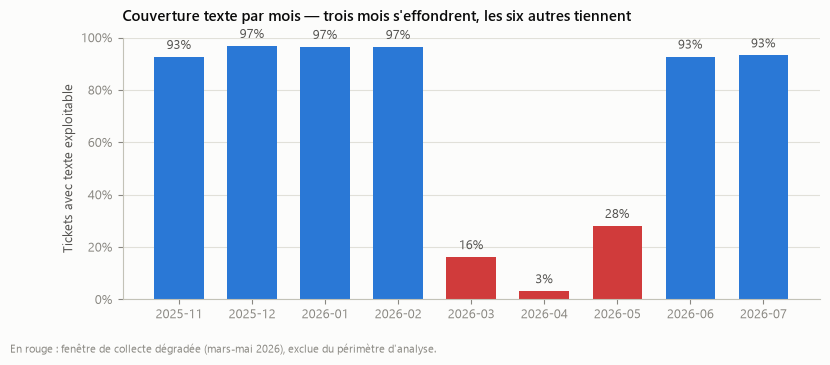

In [4]:
fig, ax = plt.subplots(figsize=(9, 3.4))
mois_str = [str(m) for m in couverture.index]
couleurs = [
    viz.STATUT["critique"] if m in config.MOIS_COLLECTE_DEGRADEE else viz.SERIES[0]
    for m in couverture.index
]
ax.bar(mois_str, couverture["couverture_texte"], color=couleurs, width=0.68)
ax.set_ylim(0, 1)
ax.yaxis.set_major_formatter(plt.matplotlib.ticker.PercentFormatter(xmax=1, decimals=0))
ax.set_title("Couverture texte par mois — trois mois s'effondrent, les six autres tiennent")
ax.grid(axis="x", visible=False)
ax.set_ylabel("Tickets avec texte exploitable", fontsize=9, color=viz.ENCRE["secondaire"])
for i, v in enumerate(couverture["couverture_texte"]):
    ax.text(i, v + 0.03, f"{v * 100:.0f}%", ha="center", fontsize=9, color=viz.ENCRE["secondaire"])
viz.annoter_source(
    fig, "En rouge : fenêtre de collecte dégradée (mars-mai 2026), exclue du périmètre d'analyse."
)
viz.sauver(fig, "03_couverture_par_mois")
plt.show()

## 2. Test de représentativité — hors fenêtre dégradée

On compare le profil des tickets **avec** texte et **sans** texte sur des
variables observables pour tous les tickets (type, canal, statut). Si les deux
groupes se ressemblent, le sous-ensemble textuel est extrapolable.

In [5]:
sain = op[~degrade].copy()
print(f"Hors fenêtre : {len(sain):,} tickets, couverture {sain['a_texte'].mean() * 100:.1f} %")

profils_sain = chargement.profil_comparatif(
    sain, sain["a_texte"], ["ticket_type_name", "channel", "ticket_state_category"]
)
for nom, table in profils_sain.items():
    chargement.sauver_table(table, f"03_representativite_sain_{nom}")
profils_sain["ticket_type_name"].head(6)

Hors fenêtre : 6,867 tickets, couverture 95.3 %
  -> resultats\tables\03_representativite_sain_ticket_type_name.csv
  -> resultats\tables\03_representativite_sain_channel.csv
  -> resultats\tables\03_representativite_sain_ticket_state_category.csv


,groupe_A_pct,groupe_B_pct,ecart_pts
ticket_type_name,,,
SARA,59.6,21.4,38.2
COMPTE,31.9,59.3,-27.4
BENEFICIAIRE ERRONE,4.7,12.1,-7.4
CARTE,1.3,1.6,-0.3
ACCUEIL,0.9,0.0,0.9
CREDIT,0.7,1.2,-0.5


In [6]:
profils_sain["channel"].head(6)

,groupe_A_pct,groupe_B_pct,ecart_pts
channel,,,
android,71.3,63.7,7.7
ios,24.0,21.4,2.6
whatsapp,4.5,13.4,-8.9
facebook,0.1,0.6,-0.5
messenger,0.1,0.9,-0.9
instagram,0.0,0.0,0.0


Des écarts existent (les tickets sans texte sont plus souvent de type COMPTE),
mais le groupe sans texte ne pèse que **4,7 %** de la période saine : quelle que
soit sa composition, son influence sur la répartition d'ensemble est marginale.

## 3. Même test — **dans** la fenêtre dégradée

C'est ici que se joue la question « peut-on quand même utiliser les 12 % de
tickets qui ont survécu à la panne ? ».

In [7]:
casse = op[degrade].copy()
print(f"Dans la fenêtre : {len(casse):,} tickets, couverture {casse['a_texte'].mean() * 100:.1f} %")

profils_casse = chargement.profil_comparatif(
    casse, casse["a_texte"], ["ticket_type_name", "channel"]
)
for nom, table in profils_casse.items():
    chargement.sauver_table(table, f"03_representativite_casse_{nom}")
profils_casse["ticket_type_name"].head(6)

Dans la fenêtre : 11,189 tickets, couverture 12.1 %
  -> resultats\tables\03_representativite_casse_ticket_type_name.csv
  -> resultats\tables\03_representativite_casse_channel.csv


,groupe_A_pct,groupe_B_pct,ecart_pts
ticket_type_name,,,
SARA,41.4,62.5,-21.1
COMPTE,38.9,21.5,17.4
BENEFICIAIRE ERRONE,14.7,0.3,14.4
CARTE,1.8,5.8,-4.0
ACCUEIL,1.3,2.0,-0.7
CREDIT,0.7,3.3,-2.7


In [8]:
profils_casse["channel"].head(6)

,groupe_A_pct,groupe_B_pct,ecart_pts
channel,,,
android,69.4,61.4,7.9
ios,28.4,17.1,11.3
whatsapp,2.1,19.7,-17.6
facebook,0.1,1.7,-1.6
instagram,0.0,0.0,-0.0


**Les écarts sont massifs.** Dans la fenêtre dégradée, les tickets qui ont
conservé du texte sur-représentent BENEFICIAIRE ERRONE (14,8 % contre 0,3 %) et
sous-représentent très fortement le canal whatsapp (2,1 % contre 19,7 %).

> Les 12 % de survivants ne sont pas un échantillon de la fenêtre : ils sont
> **sélectionnés par la panne elle-même**, qui n'a pas frappé tous les parcours
> de la même façon. En extrapoler la répartition des motifs reviendrait à
> décrire les parcours épargnés par le bug, pas les réclamations de la période.

Cette fenêtre est donc écartée — non pas parce qu'elle est incomplète, mais
parce que ce qu'il en reste est biaisé de façon connue et non corrigeable.

## 4. Le périmètre d'analyse retenu

In [9]:
analyse = chargement.perimetre_analyse(df)
analyse["texte"] = texte.construire_texte(analyse)
analyse["a_texte"] = texte.a_texte_exploitable(analyse["texte"])

base = analyse[analyse["a_texte"]]
print("PÉRIMÈTRE D'ANALYSE CAUSALE")
print(f"  mois couverts      : {', '.join(sorted(str(m) for m in analyse['mois'].unique()))}")
print(f"  tickets            : {len(analyse):,}")
print(f"  base textuelle     : {len(base):,}  ({len(base) / len(analyse) * 100:.1f} % du périmètre)")
print()
print(f"  exclus — phase pilote        : {(df['date_creation'] < config.DEBUT_PERIODE_OPERATIONNELLE).sum():,}")
print(f"  exclus — collecte dégradée   : {len(casse):,}")

PÉRIMÈTRE D'ANALYSE CAUSALE
  mois couverts      : 2025-11, 2025-12, 2026-01, 2026-02, 2026-06, 2026-07
  tickets            : 6,867
  base textuelle     : 6,545  (95.3 % du périmètre)

  exclus — phase pilote        : 38
  exclus — collecte dégradée   : 11,189


## 5. Formulation à retenir pour le rapport

> L'analyse des motifs porte sur **6 545 réclamations, soit 95,3 % des tickets
> de la période à collecte fiable** (six mois : nov. 2025 – fév. 2026 et
> juin – juil. 2026). Les 11 189 tickets de mars-mai 2026 sont exclus : la
> panne de capture du 13 mars y rend le texte à la fois absent (87,9 %) et non
> représentatif lorsqu'il est présent.

La formulation à **ne pas** employer est « l'analyse porte sur 44 % des
tickets » : elle laisse croire à un échantillon dégradé mais utilisable, alors
que le périmètre réel est plus petit, mieux défini, et presque exhaustif sur
lui-même.

**Ce n'est pas une limite, c'est un résultat** : 62 % du volume de la période
opérationnelle est structurellement inexploitable pour comprendre les causes.
Un dispositif de réclamation qui perd le motif de six réclamations sur dix est
un problème en soi, à porter au métier.